In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from src.abm2d import abm2d

from src.feature_extraction import coarsen_density

## This notebook can be used to re-create Figure 3 of the manuscript

In [2]:
# Generate simulation data with base parameter values if needed
if not os.path.isfile("../data/abm2d_base_params.npz"):
    abm2d(path = "../data",
          title = "abm2d_base_params")
out = np.load("../data/abm2d_base_params.npz")    

## Generate simulation snapshots

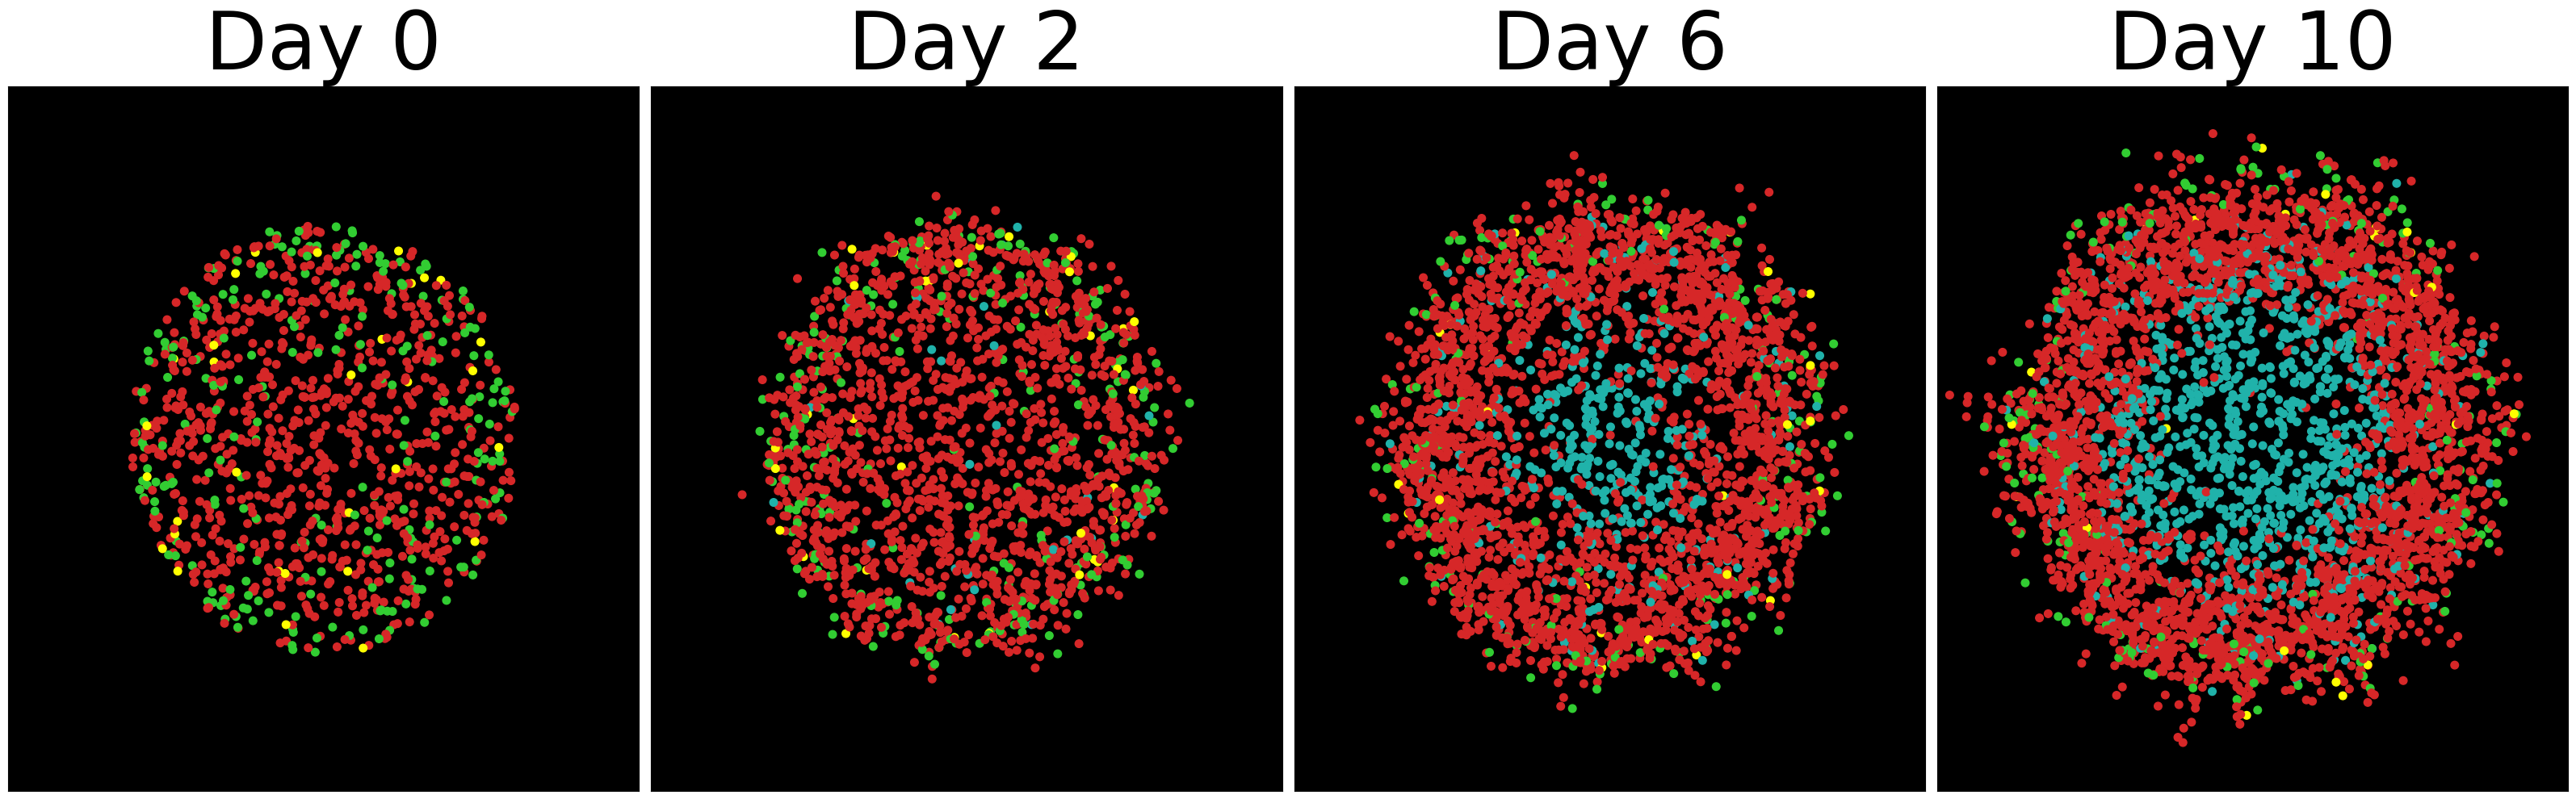

In [3]:
fig, ax  = plt.subplots(1,4, figsize=(32,10))
fontsize = 24
L = out['L']
Xs = out['X'] - L/2
Ys = out['Y'] - L/2
states = out['state'].astype(int)
for i, day in enumerate([0,2,6,10]):
    X = Xs[day]
    Y = Ys[day]
    state = states[day]
    title = f"Day {day}"
    
    colormap = np.array(["lightseagreen", "tab:red", "yellow", "limegreen"])
    ax[i].scatter(X,Y,c=colormap[state], s = 48)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(title,fontsize=3*fontsize)
    ax[i].set_xlim(-400,400)
    ax[i].set_ylim(-400,400)
    ax[i].set_facecolor('black')
    ax[i].grid(True, color = 'white', linestyle = '--')

fig.tight_layout()
fig.savefig(f'../figures/typical_abm_simulation.png')

## Plot DVs

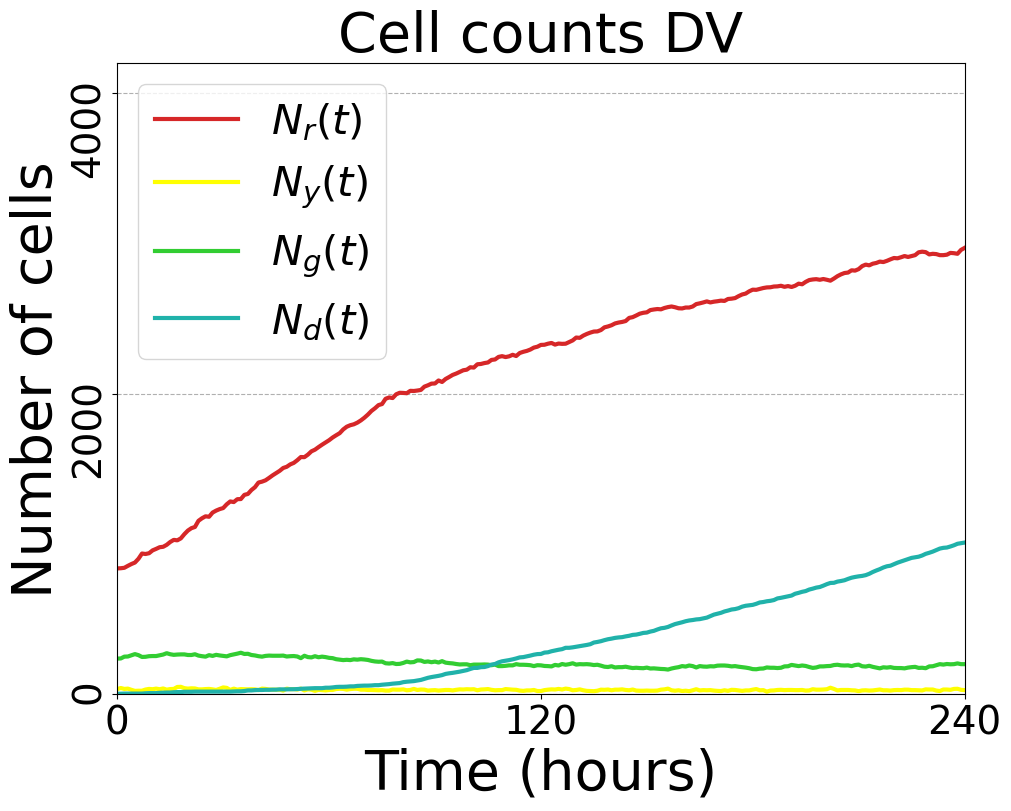

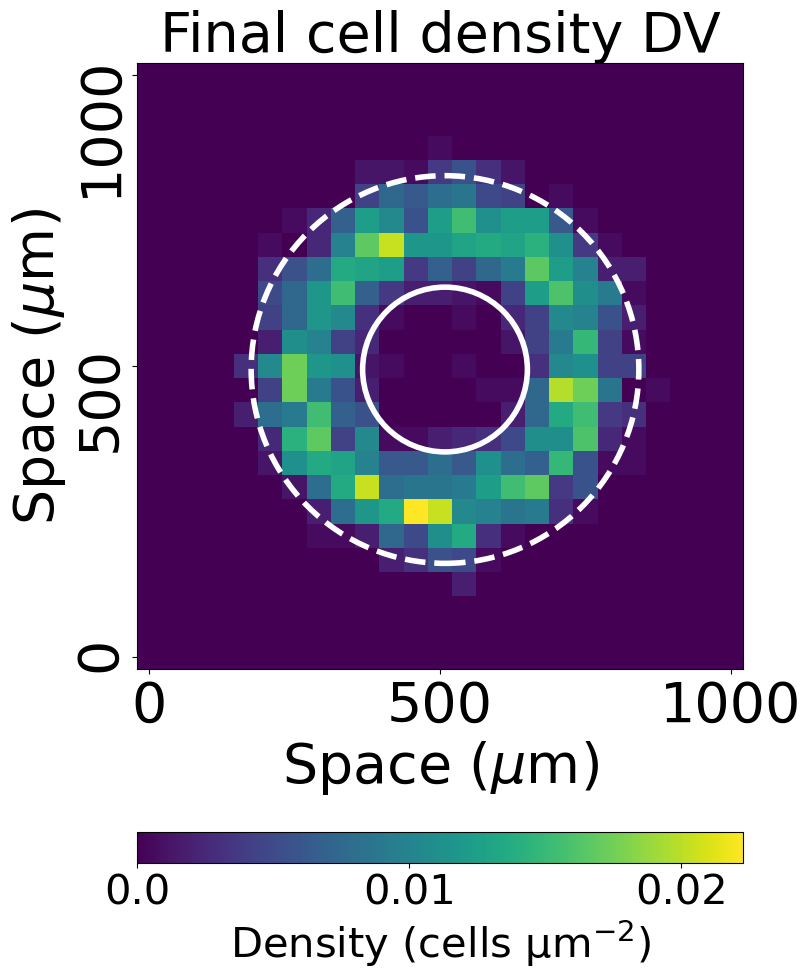

In [4]:
v = out['v']

h = out['L']/(out['I'] - 1)

Nr = out['Nr']
Ny = out['Ny']
Ng = out['Ng']
Nd = out['Nd']

fig, ax = plt.subplots(1,1, figsize = (10,8),layout="constrained")
fontsize = 40

ax.plot(np.arange(0,241), Nr,linewidth = 3, color = 'tab:red', label = '$N_r(t)$')
ax.plot(np.arange(0,241), Ny,linewidth = 3, color = 'yellow',  label = '$N_y(t)$')
ax.plot(np.arange(0,241), Ng,linewidth = 3, color = 'limegreen',  label = '$N_g(t)$')
ax.plot(np.arange(0,241), Nd,linewidth = 3, color = 'lightseagreen',  label = '$N_d(t)$')

ax.set_xlim(0,240)
ax.set_ylim(0,4300)

ax.set_ylabel('Number of cells', fontsize=fontsize)
ax.legend(loc='best', fontsize = fontsize*.7)

ax.set_xlabel('Time (hours)', fontsize=fontsize)
ax.set_title(f'Cell counts DV', fontsize=fontsize)
ax.set_ylim(0,4200)

ax.set_xticks([0,120,240],[0,120,240],fontsize=28)
ax.set_yticks([0,2e3,4e3],[0,2000,4000],fontsize=28,rotation=90)
ax.grid(axis="y",linestyle="--")
ax.legend(loc='best', fontsize = fontsize*.75)

plt.savefig('../figures/methods_overview_cell_counts.png')

fig, ax = plt.subplots(1,1, figsize = (8,10),layout="constrained")

coarseness = 8
coarse_resolution = (200//coarseness)
coarse_v = coarsen_density(v.reshape(out['I'],out['I']), I = 200, h = 1000/(199.0), bin_size = coarseness).reshape((coarse_resolution,coarse_resolution))
im = ax.imshow(coarse_v)
cbar = plt.colorbar(im, ax = ax, fraction = 0.046,orientation = 'horizontal',ticks = [0.00, 0.01, 0.02])
cbar.set_label(r'Density $(\mathrm{cells}~\mathrm{\mu m}^{-2})$', fontsize=fontsize*.75)
circle1 = plt.Circle((12.2,11.85), 3.4, color='white',fill=False,linewidth=4)
ax.add_patch(circle1)
circle1 = plt.Circle((12.2,11.85), 8, color='white',fill=False,linewidth=4,linestyle="--")
ax.add_patch(circle1)


cbar.ax.set_xticklabels([0.00, 0.01, 0.02],fontsize=fontsize*.75)

ax.set_xlabel(r'Space ($\mu$m)',fontsize=fontsize)
ax.set_ylabel(r'Space ($\mu$m)',fontsize=fontsize)

ax.set_xticks(ticks = [0, 12, 24], labels = [0, 500, 1000],fontsize=fontsize)
ax.set_yticks(ticks = [0, 12, 24], labels = [0, 500, 1000],rotation=90,fontsize=fontsize)

ax.invert_yaxis()
ax.set_title('Final cell density DV',fontsize=fontsize)\

plt.savefig('../figures/methods_overview_dens.png')

In [5]:
%load_ext watermark

%watermark -n -u -v -iv -w

Last updated: Fri May 23 2025

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.25.0

matplotlib: 3.8.4
src       : 0.0.0
numpy     : 1.26.4

Watermark: 2.5.0

